<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.



In [660]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
#get my packages that Ill be using
graph_path= '/Users/alex/Documents/Pace/Classes/Junior/Spring/Data Analytics/Assignment 2/graphing-assignment-atuosto1'
graph_data=pd.read_csv(f'{graph_path}/RealFinalDF.csv')
#gets all of my data loaded here, this is the CSV from assignment 1
graph_data.columns

Index(['Week', 'Genre', 'index', 'Play Share', 'Play Share (Number)',
       'Total Plays', 'REC', 'UNRATE', 'PCE', 'UMICH', 'Year', 'Month'],
      dtype='object')

In [661]:
linegraph=graph_data[['Genre','Play Share','Year']]
linegraph

,Genre,Play Share,Year
0,Classical,0.001522,2005
1,Electronic,0.058125,2005
2,Hip Hop,0.017911,2005
3,Indie,0.025755,2005
4,Jazz,0.133868,2005
...,...,...,...
5043,folk,0.028571,2025
5044,other,0.828571,2025
5045,Pop,0.050000,2025
5046,other,0.950000,2025


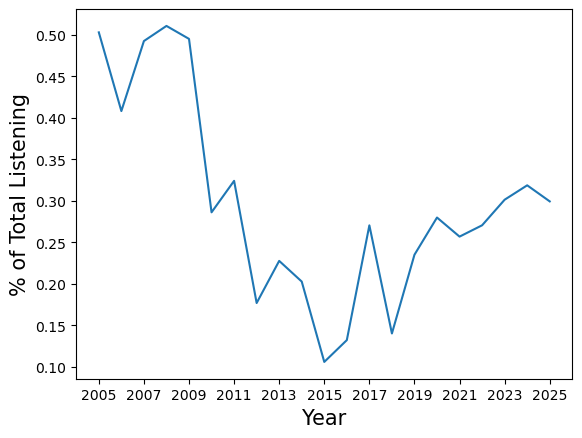

In [662]:
genres= linegraph['Genre'].unique()

rock=linegraph[linegraph['Genre']=='Rock']
groupedrock=rock.groupby('Year',as_index=False)['Play Share'].mean() #https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
#just doing this for rock but I'll eventually make a for loop to get this for every single Genre
rockgraph=plt.plot(groupedrock['Year'],groupedrock['Play Share'])
plt.xticks([i for i in range(2005,2026,2)])
plt.xlabel('Year',fontsize=15)
plt.ylabel('% of Total Listening', fontsize=15)
plt.show()

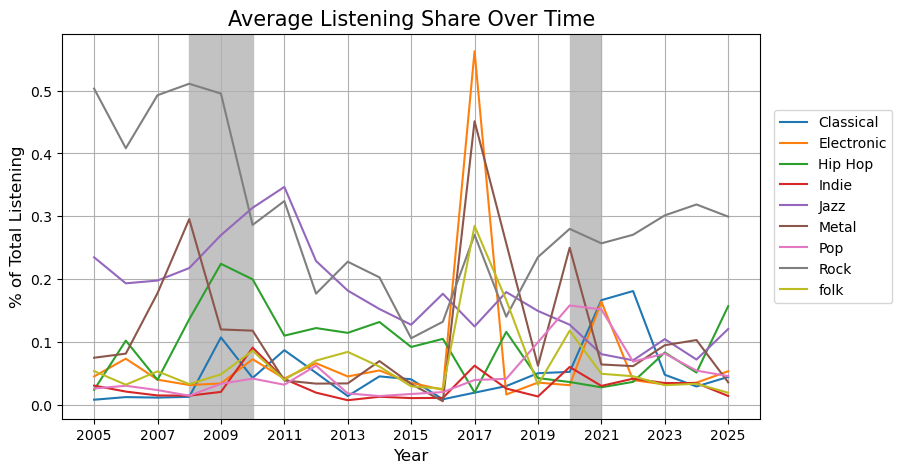

In [675]:
plt.figure(figsize=(9,5))


genres= linegraph['Genre'].unique()
for genre in genres:
    if genre!= 'other': #other makes up a large part of the data but tells me nothing so im leaving it out
        gen=linegraph[linegraph['Genre']==f'{genre}'] #love a good F string, cycles the genre comparing it to the genre in the loop
        groupedgen=gen.groupby('Year',as_index=False)['Play Share'].mean() #https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
    #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
    # groups my genre data by year, keeps a different index so the year is still its own column, and brings the mean of the play share for each year 
        gengraph=plt.plot(groupedgen['Year'],groupedgen['Play Share'], label=genre) # x is year, y is play share, label is the genre for the legend
        plt.xticks([i for i in range(2005,2026,2)]) # plots my years
        plt.xlabel('Year',fontsize=12) # makes x label ' year' and the font size of 12
        plt.ylabel('% of Total Listening', fontsize=12) #same as above just for the y label
        plt.title('Average Listening Share Over Time', fontsize=15) #makes the title with fontsize 15
    else:
        pass

recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2') #https://stackoverflow.com/questions/65344945/how-to-create-a-plot-with-vertical-shades-in-matplotlib
#looks at a date and makes the grey bars for each of the recession years
plt.legend(bbox_to_anchor=(1.2,0.82),loc='upper right') #puts the big legend roughly in the middle i tried to make it look close to the middle 
plt.grid()
plt.savefig(graph_path+'/SpaghettiGraph.png', dpi = 500, transparent=False,bbox_inches='tight') #https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off
plt.show()


### Changing this to be a better spaghetti graph

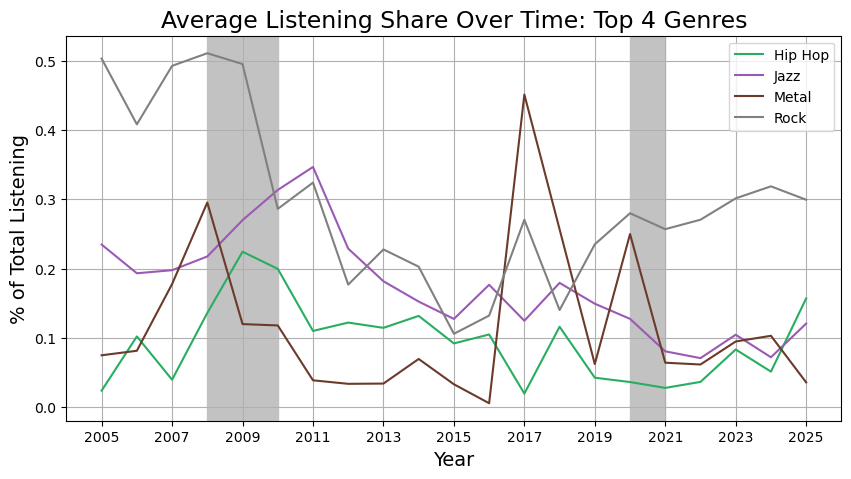

In [664]:
plt.figure(figsize=(10,5))

top4= linegraph[(linegraph['Genre']=='Rock')|(linegraph['Genre']=='Jazz')|
    (linegraph['Genre']=='Metal')|(linegraph['Genre']=='Hip Hop')] # get each of the top 4 artists 
top4unique=top4['Genre'].unique() #get the unique genre names from top4
colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'} # sets my colors into a dictionary that my loop can pull from
for genre in top4unique:
    gen=top4[top4['Genre']==genre] #love a good F string, cycles the genre comparing it to the genre in the loop
    groupedgen=gen.groupby('Year',as_index=False)['Play Share'].mean() #https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
    #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
    # groups my genre data by year, keeps a different index so the year is still its own column, and brings the mean of the play share for each year 
    gengraph=plt.plot(groupedgen['Year'],groupedgen['Play Share'], label=genre, color=colors[genre]) # x is year, y is play share, label is the genre for the legend
    plt.xticks([i for i in range(2005,2026,2)]) # plots my years
    plt.xlabel('Year',fontsize=14) # makes x label ' year' and the font size of 12
    plt.ylabel('% of Total Listening', fontsize=14) #same as above just for the y label
    plt.title('Average Listening Share Over Time: Top 4 Genres', fontsize=17) #makes the title with fontsize 17
    

recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2') #https://stackoverflow.com/questions/65344945/how-to-create-a-plot-with-vertical-shades-in-matplotlib
#looks at a date and makes the grey bars for each of the recession years
plt.legend(bbox_to_anchor=(1,1),loc='upper right')
plt.grid()
plt.savefig(graph_path+'/MeanListeningShare.png', dpi = 300, transparent=False)
plt.show()

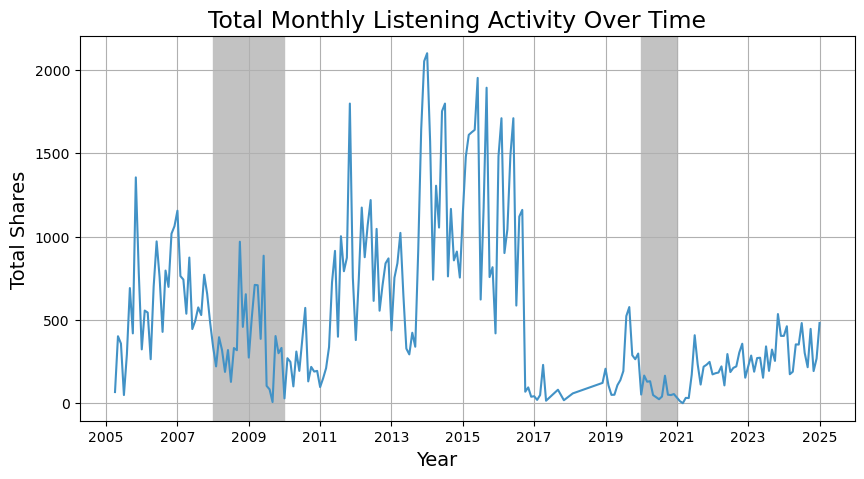

In [665]:
plays_monthly = graph_data.groupby(['Year', 'Month'])['Play Share (Number)'].sum().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
clean=plays_monthly.drop_duplicates().reset_index() #cleaning my data for this graph
clean=clean[(clean['Year']!=2005)|(clean['Month']!=2)] #excludes february of 2005 as there was a huge outlier in this month
clean=clean[clean['Year']<2025] #matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) #creates the size for the charts
plt.plot(clean['Year']+clean['Month']/12,clean['Play Share (Number)'],color='#4292C6') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was a gross ugly step function before
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2')
plt.title('Total Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
plt.xlabel('Year', fontsize=14,horizontalalignment='right', x=0.487)#https://stackoverflow.com/questions/38186072/how-to-align-axis-label-to-the-right-or-top-in-matplotlib#:~:text=3%20Answers,5%20Comments
plt.ylabel('Total Shares', fontsize=14, horizontalalignment='right', y=0.65)
plt.xticks([i for i in range(2005,2026,2)])
plt.grid()
plt.savefig(graph_path+'/MonthTotal.png', dpi = 300, transparent=False)
plt.show()

In [666]:
plays_monthly

,Year,Month,Play Share (Number)
0,2005,2,17384.0
1,2005,3,68.0
2,2005,4,403.0
3,2005,5,359.0
4,2005,6,50.0
...,...,...,...
229,2025,8,248.0
230,2025,9,127.0
231,2025,10,479.0
232,2025,11,387.0


### INTERPRETATION
##### These two line charts help to show the overall trend experienced by this use when examining listening patterns in music. 
##### We can see that there appears to be some kind of decline in listening during recessions even though this relationship may not be extremely accurate as during 2008's recession we can see a clearly volatile period.
##### My hypothesis that people will listen to more music during recessions is looking like it might not come out as statistically significant... unfortunately.

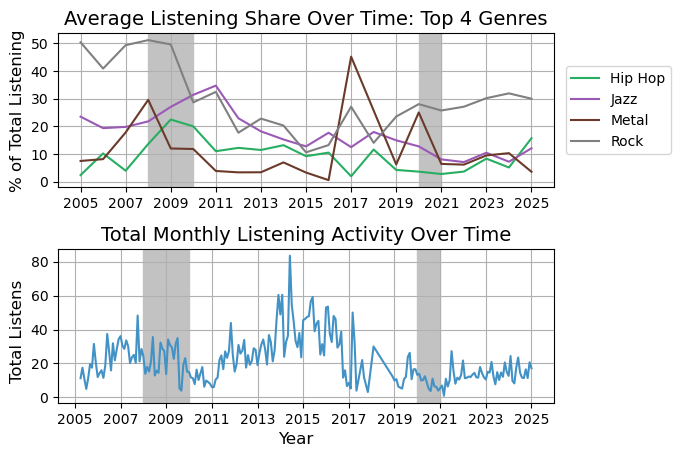

In [676]:
fig, ax = plt.subplots(nrows = 2, ncols = 1)
ax1=plt.subplot(2,1,1)
top4= linegraph[(linegraph['Genre']=='Rock')|(linegraph['Genre']=='Jazz')|
    (linegraph['Genre']=='Metal')|(linegraph['Genre']=='Hip Hop')] # visually looking at the last graph i picked these top 4
top4unique=top4['Genre'].unique() #get each of the unique genres
colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'}
for genre in top4unique:
    gen=top4[top4['Genre']==genre] #cycles the genre comparing it to the genre in the loop
    groupedgen=gen.groupby('Year',as_index=False)['Play Share'].mean() #https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
    #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
    # groups my genre data by year, keeps a different index so the year is still its own column, and brings the mean of the play share for each year 
    gengraph=ax1.plot(groupedgen['Year'],groupedgen['Play Share']*100, label=genre, color=colors[genre]) # x is year, y is play share, label is the genre for the legend
    ax1.set_xticks([i for i in range(2005,2026,2)]) # plots my years 2005-2026 on the x axis
    ax1.set_yticks([i for i in range(0,60,10)]) #sets y labels from 0 - 60 in percentage terms on the y axis
    ax1.set_ylabel('% of Total Listening', fontsize=12) #same as above just for the y label
    ax1.set_title('Average Listening Share Over Time: Top 4 Genres', fontsize=14) #makes the title with fontsize 15
recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     ax1.axvspan(year,year+1, color='#C2C2C2') #plots recession blocks
ax1.grid() # puts gridlines in the graph
ax1.legend(loc='right',bbox_to_anchor=(1.25,.5)) #moves the legend to be roughly in the middle

ax2=plt.subplot(2,1,2)
ax2.plot(clean['Year']+clean['Month']/12,clean['Play Share (Number)'], color='#4292C6') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to plot each month instead of yearly, it was a gross ugly step function before
for year in recession:
     ax2.axvspan(year,year+1, color='#C2C2C2')
ax2.set_title('Total Monthly Listening Activity Over Time', fontsize=14, horizontalalignment='center', x = .5)
ax2.set_xlabel('Year', fontsize=12,horizontalalignment='right', x=0.515)#https://stackoverflow.com/questions/38186072/how-to-align-axis-label-to-the-right-or-top-in-matplotlib#:~:text=3%20Answers,5%20Comments
ax2.set_ylabel('Total Listens', fontsize=12, horizontalalignment='right', y=0.8)
ax2.set_xticks([i for i in range(2005,2026,2)]) #sets my x axis values equal to these years
ax2.grid()

plt.subplots_adjust(hspace=0.4) #puts a little space between the two
plt.savefig(graph_path+'/2Graphs.png', dpi = 300, transparent=False,bbox_inches='tight')#https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off
plt.show()

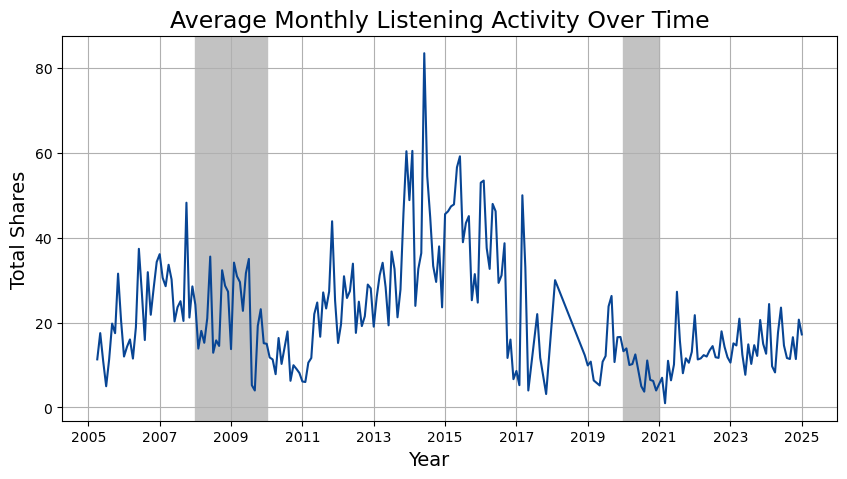

In [668]:
plays_monthly = graph_data.groupby(['Year', 'Month'])['Play Share (Number)'].mean().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
clean=plays_monthly.drop_duplicates().reset_index() #cleaning my data for this graph
clean=clean[(clean['Year']!=2005)|(clean['Month']!=2)] #excludes february of 2005 as there was a huge outlier in this month
clean=clean[clean['Year']<2025] #matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) #creates the size for the charts
plt.plot(clean['Year']+clean['Month']/12,clean['Play Share (Number)'],color='#084594') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was a gross ugly step function before
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2')
plt.title('Average Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
plt.xlabel('Year', fontsize=14,horizontalalignment='right', x=0.5)#https://stackoverflow.com/questions/38186072/how-to-align-axis-label-to-the-right-or-top-in-matplotlib#:~:text=3%20Answers,5%20Comments
plt.ylabel('Total Shares', fontsize=14, horizontalalignment='right', y=0.65)
plt.xticks([i for i in range(2005,2026,2)])
plt.grid()
plt.savefig(graph_path+'/MeanMonthlyListen.png', dpi = 300, transparent=False)
plt.show()

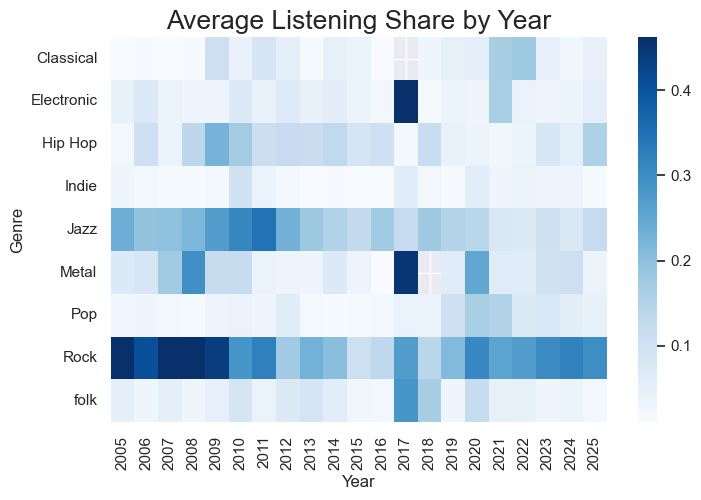

In [678]:
sns.set(font_scale=1)# sets the font size for the heatmap
plt.figure(figsize=(8,5))# makes the general blank figure
heatmap=linegraph[linegraph['Genre']!='other'] #makes the heatmap data the linegraph data as well
#just drops the other category
heatmapdata = heatmap[['Year','Genre', 'Play Share']].drop_duplicates() #puts all the data we need into one dataframe
hm = heatmapdata.pivot_table(index= 'Genre',columns = 'Year',values = 'Play Share',aggfunc='mean')
#I found this out at the links below, since I have 2 category variables this is considered a 3d pivot table
#that means I had to do the pivot table function instead of just pivot like we had in the lecture
#i also had to use the aggfunc which basically means that each of the index values will be the mean for each year for each Genre
#https://seaborn.pydata.org/generated/seaborn.heatmap.html
#https://stackoverflow.com/questions/69968235/pivot-table-in-proper-order-for-the-heatmap
#https://saturncloud.io/blog/pandas-pivot-table-list-of-aggfunc-a-guide/
plt.title('Average Listening Share by Year', fontsize=19)
sns.heatmap(hm, cmap='Blues', robust= True) #gets my data, my continuous mapping, and looks at the robust percentiles (98th% and 2nd% true)
plt.savefig(graph_path+'/Heatmap.png', dpi = 300, transparent=False, bbox_inches='tight')
plt.show()


In [670]:
sns.reset_orig()
#this resets the seaborn theme because I nearly had a heart attack when I changed the theme and my other graphs changed
